## Predicting NHL Shot Outcomes: Goal Probability Analysis

#### Significance

In the NHL, data and prediction modeling plays a key variable in player training and team preparation. Traditional hockey metrics often rely on raw shot data. but something this method has lacked is highlighting the threat the other team. Of a given play, teams and their coaches should be able to reliably predict the actions of another team, without any surpises. Advanced machine learning models, including expected goals, aim to quantify the quality of a shot based on its characteristics. By understanding the behaviors of goals, coaches can better evaluate player decision-making, and identify offensive and defensive vulnerabilities that pose themselves on the ice.

#### Goal

Our current task is to develop a calibrated probability model that estimates the probability of an NHL shot, based on characteristics of the pitch thrown and other situational aspects. Specifically, this is a binary classification problem: identifying ```Goal``` (1) or ```Shot-on-Goal``` (0). This model analyzes and measures the likelihood of a specific shot being a ```Goal```.

#### Note: 
The data used in this project was first scraped from the NHL API into a JSON file, manipulated using Python, and stored in a SQLite database for efficient data extraction and querying.

In [71]:
import pandas as pd
import json
import sqlite3

# machine learning imports
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.neighbors import KNeighborsRegressor,KNeighborsClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import (root_mean_squared_error, accuracy_score,  mean_absolute_percentage_error,mean_absolute_error,
fbeta_score,make_scorer,precision_score,recall_score)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [72]:
#load the JSON file
with open('shots.json') as f:
    data = json.load(f)
#adjust and flatten the data to be in a format that can be easily analyzed
df = pd.json_normalize(data)

In [73]:
#ensudre dataframe is split correctly
df

,eventId,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,periodDescriptor.number,periodDescriptor.periodType,...,details.assist2PlayerId,details.assist2PlayerTotal,details.awayScore,details.homeScore,details.discreteClip,details.highlightClipSharingUrl,details.highlightClip,details.discreteClipFr,details.highlightClipSharingUrlFr,details.highlightClipFr
0,53,00:41,19:19,1551,right,506,shot-on-goal,13,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,01:27,18:33,1551,right,506,shot-on-goal,25,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,67,01:30,18:30,1551,right,506,shot-on-goal,30,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,72,02:15,17:45,1551,right,506,shot-on-goal,38,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,79,02:34,17:26,1551,right,506,shot-on-goal,46,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5574,1022,16:04,03:56,1551,right,506,shot-on-goal,725,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5575,1043,17:33,02:27,1551,right,506,shot-on-goal,739,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5576,1053,18:03,01:57,1551,right,506,shot-on-goal,748,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5577,1065,19:00,01:00,1551,right,506,shot-on-goal,758,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
with pd.option_context('display.max_columns', None):
    display(df)

,eventId,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,periodDescriptor.number,periodDescriptor.periodType,periodDescriptor.maxRegulationPeriods,details.xCoord,details.yCoord,details.zoneCode,details.shotType,details.shootingPlayerId,details.goalieInNetId,details.eventOwnerTeamId,details.awaySOG,details.homeSOG,pptReplayUrl,details.scoringPlayerId,details.scoringPlayerTotal,details.assist1PlayerId,details.assist1PlayerTotal,details.assist2PlayerId,details.assist2PlayerTotal,details.awayScore,details.homeScore,details.discreteClip,details.highlightClipSharingUrl,details.highlightClip,details.discreteClipFr,details.highlightClipSharingUrlFr,details.highlightClipFr
0,53,00:41,19:19,1551,right,506,shot-on-goal,13,1,REG,3,71.0,5.0,O,wrist,8482702.0,8481020.0,25,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,01:27,18:33,1551,right,506,shot-on-goal,25,1,REG,3,-45.0,-4.0,O,wrist,8479439.0,8476433.0,21,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,67,01:30,18:30,1551,right,506,shot-on-goal,30,1,REG,3,-31.0,3.0,O,slap,8480157.0,8476433.0,21,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,72,02:15,17:45,1551,right,506,shot-on-goal,38,1,REG,3,-88.0,29.0,D,wrist,8484146.0,8481020.0,25,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,79,02:34,17:26,1551,right,506,shot-on-goal,46,1,REG,3,-51.0,-26.0,O,wrist,8480073.0,8476433.0,21,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5574,1022,16:04,03:56,1551,right,506,shot-on-goal,725,3,REG,3,-64.0,-25.0,O,slap,8480336.0,8477992.0,12,15.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5575,1043,17:33,02:27,1551,right,506,shot-on-goal,739,3,REG,3,-43.0,39.0,O,slap,8478427.0,8477992.0,12,15.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5576,1053,18:03,01:57,1551,right,506,shot-on-goal,748,3,REG,3,28.0,17.0,O,slap,8478178.0,8481611.0,14,16.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5577,1065,19:00,01:00,1551,right,506,shot-on-goal,758,3,REG,3,-48.0,-33.0,O,wrist,8476906.0,8477992.0,12,16.0,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
df[df['typeDescKey'] == 'goal']

,eventId,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,periodDescriptor.number,periodDescriptor.periodType,...,details.assist2PlayerId,details.assist2PlayerTotal,details.awayScore,details.homeScore,details.discreteClip,details.highlightClipSharingUrl,details.highlightClip,details.discreteClipFr,details.highlightClipSharingUrlFr,details.highlightClipFr
13,156,14:23,05:37,1531,right,505,goal,197,1,REG,...,8482145.0,1.0,1.0,0.0,6.362371e+12,NaN,NaN,NaN,NaN,NaN
16,398,15:55,04:05,1551,right,505,goal,217,1,REG,...,8485105.0,1.0,1.0,1.0,6.362370e+12,NaN,NaN,NaN,NaN,NaN
33,729,12:20,07:40,1351,left,505,goal,445,2,REG,...,8479439.0,1.0,1.0,2.0,6.362374e+12,https://nhl.com/video/,6.362371e+12,NaN,NaN,NaN
48,897,05:11,14:49,1551,right,505,goal,612,3,REG,...,8476278.0,1.0,2.0,2.0,6.362374e+12,NaN,NaN,NaN,NaN,NaN
62,1073,20:00,00:00,1551,right,505,goal,790,3,REG,...,8480950.0,1.0,3.0,2.0,6.362374e+12,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5520,950,08:07,11:53,1551,right,505,goal,650,3,REG,...,8480883.0,1.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
5527,1137,18:38,01:22,1351,right,505,goal,789,3,REG,...,8480883.0,2.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN
5547,659,05:26,14:34,1551,left,505,goal,339,2,REG,...,8480830.0,1.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
5549,687,08:30,11:30,1551,left,505,goal,371,2,REG,...,8477463.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
##### DATA DICTIONARY HERE #####

In [77]:
df.columns

Index(['eventId', 'timeInPeriod', 'timeRemaining', 'situationCode',
       'homeTeamDefendingSide', 'typeCode', 'typeDescKey', 'sortOrder',
       'periodDescriptor.number', 'periodDescriptor.periodType',
       'periodDescriptor.maxRegulationPeriods', 'details.xCoord',
       'details.yCoord', 'details.zoneCode', 'details.shotType',
       'details.shootingPlayerId', 'details.goalieInNetId',
       'details.eventOwnerTeamId', 'details.awaySOG', 'details.homeSOG',
       'pptReplayUrl', 'details.scoringPlayerId', 'details.scoringPlayerTotal',
       'details.assist1PlayerId', 'details.assist1PlayerTotal',
       'details.assist2PlayerId', 'details.assist2PlayerTotal',
       'details.awayScore', 'details.homeScore', 'details.discreteClip',
       'details.highlightClipSharingUrl', 'details.highlightClip',
       'details.discreteClipFr', 'details.highlightClipSharingUrlFr',
       'details.highlightClipFr'],
      dtype='object')

In [78]:
df

,eventId,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,periodDescriptor.number,periodDescriptor.periodType,...,details.assist2PlayerId,details.assist2PlayerTotal,details.awayScore,details.homeScore,details.discreteClip,details.highlightClipSharingUrl,details.highlightClip,details.discreteClipFr,details.highlightClipSharingUrlFr,details.highlightClipFr
0,53,00:41,19:19,1551,right,506,shot-on-goal,13,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,01:27,18:33,1551,right,506,shot-on-goal,25,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,67,01:30,18:30,1551,right,506,shot-on-goal,30,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,72,02:15,17:45,1551,right,506,shot-on-goal,38,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,79,02:34,17:26,1551,right,506,shot-on-goal,46,1,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5574,1022,16:04,03:56,1551,right,506,shot-on-goal,725,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5575,1043,17:33,02:27,1551,right,506,shot-on-goal,739,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5576,1053,18:03,01:57,1551,right,506,shot-on-goal,748,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5577,1065,19:00,01:00,1551,right,506,shot-on-goal,758,3,REG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
#turn typeDescKey to 0 or 1, one hot encode

In [80]:
print(df.dtypes)

eventId                                    int64
timeInPeriod                              object
timeRemaining                             object
situationCode                             object
homeTeamDefendingSide                     object
typeCode                                   int64
typeDescKey                               object
sortOrder                                  int64
periodDescriptor.number                    int64
periodDescriptor.periodType               object
periodDescriptor.maxRegulationPeriods      int64
details.xCoord                           float64
details.yCoord                           float64
details.zoneCode                          object
details.shotType                          object
details.shootingPlayerId                 float64
details.goalieInNetId                    float64
details.eventOwnerTeamId                   int64
details.awaySOG                          float64
details.homeSOG                          float64
pptReplayUrl        

In [81]:
type('timeRemaining')

str

In [82]:
df.columns

Index(['eventId', 'timeInPeriod', 'timeRemaining', 'situationCode',
       'homeTeamDefendingSide', 'typeCode', 'typeDescKey', 'sortOrder',
       'periodDescriptor.number', 'periodDescriptor.periodType',
       'periodDescriptor.maxRegulationPeriods', 'details.xCoord',
       'details.yCoord', 'details.zoneCode', 'details.shotType',
       'details.shootingPlayerId', 'details.goalieInNetId',
       'details.eventOwnerTeamId', 'details.awaySOG', 'details.homeSOG',
       'pptReplayUrl', 'details.scoringPlayerId', 'details.scoringPlayerTotal',
       'details.assist1PlayerId', 'details.assist1PlayerTotal',
       'details.assist2PlayerId', 'details.assist2PlayerTotal',
       'details.awayScore', 'details.homeScore', 'details.discreteClip',
       'details.highlightClipSharingUrl', 'details.highlightClip',
       'details.discreteClipFr', 'details.highlightClipSharingUrlFr',
       'details.highlightClipFr'],
      dtype='object')

In [83]:
#pull dataframe to SQL database for storage

connection = sqlite3.connect('hockey_data.db')
cursor = connection.cursor()
# df.to_sql('shots', connection, index = False)
# cursor = connection.cursor()

In [84]:
cursor.execute("DROP TABLE IF EXISTS shots2")
cursor.execute('''
CREATE TABLE shots2 (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    eventID INTEGER,
    timeRemaining TEXT,
    situationCode TEXT,
    homeTeamDefendingSide TEXT,
    typeDescKey TEXT,
    "periodDescriptor.number" INTEGER,
    "periodDescriptor.periodType" TEXT,
    "periodDescriptor.maxRegulationPeriods" INTEGER,
    "details.xCoord" FLOAT,
    "details.yCoord" FLOAT,
    "details.zoneCode" TEXT,
    "details.shotType" TEXT,
    "details.awaySOG" FLOAT,
    "details.homeSOG" FLOAT
);
''')

In [85]:
#insert data into the new table from json file
into = '''
INSERT INTO shots2 (
    eventID, 
    timeRemaining, 
    situationCode, 
    homeTeamDefendingSide, 
    typeDescKey, 
    "periodDescriptor.number", 
    "periodDescriptor.periodType", 
    "periodDescriptor.maxRegulationPeriods", 
    "details.xCoord", 
    "details.yCoord", 
    "details.zoneCode", 
    "details.shotType", 
    "details.awaySOG", 
    "details.homeSOG"
) VALUES (
    :eventId, :timeRemaining, :situationCode, :homeTeamDefendingSide, 
    :typeDescKey, :period_num, :period_type, :period_max, 
    :x, :y, :zone, :shot_type, :away_sog, :home_sog
);
'''

formatted_data = []
for row in data:
    details = row.get('details', {})
    period = row.get('periodDescriptor', {})
    entry = {
        'eventId': row.get('eventId'),
        'timeRemaining': row.get('timeRemaining'),
        'situationCode': row.get('situationCode'),
        'homeTeamDefendingSide': row.get('homeTeamDefendingSide'),
        'typeDescKey': row.get('typeDescKey'),
        'period_num': period.get('number'),
        'period_type': period.get('periodType'),
        'period_max': period.get('maxRegulationPeriods'),
        'x': details.get('xCoord'),
        'y': details.get('yCoord'),
        'zone': details.get('zoneCode'),
        'shot_type': details.get('shotType'),
        'away_sog': details.get('awaySOG'),
        'home_sog': details.get('homeSOG')
    }
    formatted_data.append(entry)

cursor.executemany(into, formatted_data)
connection.commit()

In [86]:
join = '''
SELECT * 
FROM new_table
LEFT JOIN hockey_data
ON new_table.eventID = hockey_data.eventID'''

In [87]:
print(len(data))

5579


In [88]:
cursor.execute("SELECT COUNT(*) FROM shots2")
row_count = cursor.fetchone()[0]
print(f"Number of rows: {row_count}")


Number of rows: 5579


### Data Dictionary

| Column Name | Data Type |Definition | 
| ----------- |  ---------- | -----    |
|typeDescKey | String | Target Variable, the outcome of the current play (goal or no goal)|
| periodDescriptor.number | Integer | The period index of the game (OT - OVER TIME)| 
| details.xCoord | Float | Longitudinal Coordinate |
| details.yCoord | Float | Longitudinal Coordinate |
| detail.shotType | String | Technique used in the shot | 
|details.zoneCode | String | The area of the ice where the shot occurred (O : Offensive, N = Neutral, D : Defensive)|
|details.shotType | String | Type of shot by player on ice | 
|details.awaySOG | Float | Away game shot-on-goal count|
|details.homeSOG | Float | Home game shot-on-goal count|

### Summary Statistics

### Data Cleaning

In [89]:
len(df)

5579

In [90]:
df.isna().sum()

eventId                                     0
timeInPeriod                                0
timeRemaining                               0
situationCode                               0
homeTeamDefendingSide                       3
typeCode                                    0
typeDescKey                                 0
sortOrder                                   0
periodDescriptor.number                     0
periodDescriptor.periodType                 0
periodDescriptor.maxRegulationPeriods       0
details.xCoord                              3
details.yCoord                              3
details.zoneCode                            3
details.shotType                            3
details.shootingPlayerId                  631
details.goalieInNetId                      56
details.eventOwnerTeamId                    0
details.awaySOG                           631
details.homeSOG                           631
pptReplayUrl                             4968
details.scoringPlayerId           

Modify original dataframe to drop rows with missing values, since there are only a few and we want to focus on analyzing the data we do have  

In [91]:
len(df)

5579

In [92]:
#drop columns that are not relevant to our analysis, such as player IDs and clip URLs, since we want to focus on analyzing the shot data itself
to_drop = [
    'timeRemaining', 'situationCode', 'details.shootingPlayerId', 'details.goalieInNetId', 'details.eventOwnerTeamId',
    'pptReplayUrl', 'details.scoringPlayerId', 'details.scoringPlayerTotal',
    'details.assist1PlayerId', 'details.assist1PlayerTotal',
    'details.assist2PlayerId', 'details.assist2PlayerTotal',
    'details.discreteClip', 'details.highlightClipSharingUrl', 'details.highlightClip',
    'details.discreteClipFr', 'details.highlightClipSharingUrlFr', 'details.highlightClipFr',
    'timeInPeriod', 'sortOrder', 'typeCode','details.awayScore','details.homeScore', 
    'periodDescriptor.maxRegulationPeriods', 'eventId'
]

df = df.drop(columns=to_drop)

##### Typically, we drop duplicates in data cleaning. However, in the case of this data, ID duplicates indicate a shot taken during the same game or period. Throughout this analysis, ID duplicates won't hurt or skew our findings.

In [93]:
df['target'] = df['typeDescKey']
df['target'] = df['target'].apply(lambda x: 1 if x == 'goal' else 0)
df

,homeTeamDefendingSide,typeDescKey,periodDescriptor.number,periodDescriptor.periodType,details.xCoord,details.yCoord,details.zoneCode,details.shotType,details.awaySOG,details.homeSOG,target
0,right,shot-on-goal,1,REG,71.0,5.0,O,wrist,1.0,0.0,0
1,right,shot-on-goal,1,REG,-45.0,-4.0,O,wrist,1.0,1.0,0
2,right,shot-on-goal,1,REG,-31.0,3.0,O,slap,1.0,2.0,0
3,right,shot-on-goal,1,REG,-88.0,29.0,D,wrist,2.0,2.0,0
4,right,shot-on-goal,1,REG,-51.0,-26.0,O,wrist,2.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...
5574,right,shot-on-goal,3,REG,-64.0,-25.0,O,slap,15.0,30.0,0
5575,right,shot-on-goal,3,REG,-43.0,39.0,O,slap,15.0,31.0,0
5576,right,shot-on-goal,3,REG,28.0,17.0,O,slap,16.0,31.0,0
5577,right,shot-on-goal,3,REG,-48.0,-33.0,O,wrist,16.0,32.0,0


In [94]:
df['sog_diff'] = abs(df['details.awaySOG'] - df['details.homeSOG'])
df['sog_diff']

0        1.0
1        0.0
2        1.0
3        0.0
4        1.0
        ... 
5574    15.0
5575    16.0
5576    15.0
5577    16.0
5578     NaN
Name: sog_diff, Length: 5579, dtype: float64

##### Here, we will ignore the NaN values. To remove the NaN values would remove some useful data. Instead, we can take the NaN values and input 0's for them.

In [95]:
df["sog_diff"] = df['sog_diff'].fillna(0)
df['sog_diff']

0        1.0
1        0.0
2        1.0
3        0.0
4        1.0
        ... 
5574    15.0
5575    16.0
5576    15.0
5577    16.0
5578     0.0
Name: sog_diff, Length: 5579, dtype: float64

#### Now, we need to conduct One-hot Encoding to see the correlation between our variables. 

In [96]:
df.dtypes

homeTeamDefendingSide           object
typeDescKey                     object
periodDescriptor.number          int64
periodDescriptor.periodType     object
details.xCoord                 float64
details.yCoord                 float64
details.zoneCode                object
details.shotType                object
details.awaySOG                float64
details.homeSOG                float64
target                           int64
sog_diff                       float64
dtype: object

In [97]:
#define categorical columns to encode
# categorical_cols = ['details.shotType', 'details.zoneCode', 'homeTeamDefendingSide',
#                     'periodDescriptor.periodType', 'homeTeamDefendingSide',
#                     'homeTeamDefendingSide', 'details.zoneCode', 'details.shotType']

# # apply One-Hot Encoding
# # 'drop_first=True' is used to avoid multicollinearity
# df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [98]:
# df_encoded.head()

In [99]:
# df_encoded.columns

In [100]:
# separate target variable from features
# df_encoded = df_encoded.drop(columns = ['target', 'typeDescKey'])
# df_encoded.columns

In [101]:
# df_encoded

In [102]:
df = df.drop(columns = ['typeDescKey'])
df.columns

Index(['homeTeamDefendingSide', 'periodDescriptor.number',
       'periodDescriptor.periodType', 'details.xCoord', 'details.yCoord',
       'details.zoneCode', 'details.shotType', 'details.awaySOG',
       'details.homeSOG', 'target', 'sog_diff'],
      dtype='object')

In [103]:
#train test split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
#check the shape of the test set to ensure the split was successful
df_test.shape[0]/df.shape[0]

0.20003584871840832

In [104]:
df.columns

Index(['homeTeamDefendingSide', 'periodDescriptor.number',
       'periodDescriptor.periodType', 'details.xCoord', 'details.yCoord',
       'details.zoneCode', 'details.shotType', 'details.awaySOG',
       'details.homeSOG', 'target', 'sog_diff'],
      dtype='object')

In [105]:
#create X and y for training and test data 

X_train = df_train.drop(columns=['target'])
y_train = df_train['target']

X_test = df_test.drop(columns=['target'])
y_test = df_test['target'] 

In [106]:
strings = X_train.select_dtypes(include = ['object']).columns.tolist()
nums=X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [107]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(12, 10))
# sns.heatmap(subset, annot=True, cmap='coolwarm', fmt='.2f')
# plt.show()


#### Multicolliniarity?

It is best practice to question why we see NaN values in the correlation matrix. We must acknowledge the variables used to predict in this scenario. We are using the period to 

In [108]:
from sklearn.svm import SVC

In [109]:
# train models
numeric_processor = Pipeline(
    steps = [
        ("MedianImputer", SimpleImputer(strategy='median')),
        ("Standardize", StandardScaler())
    ]
)
cat_processor = Pipeline(
    steps = [
        ("ModalImputer", SimpleImputer(strategy='most_frequent')),
        ("OneHotEncoder", OneHotEncoder(handle_unknown="infrequent_if_exist", max_categories=5)),
    ]
)
preprocessor = ColumnTransformer(
    transformers = [
        ("CategoricalProcessing", cat_processor, strings),
        ("NumericalProcessing", numeric_processor, nums)
    ],
    remainder="drop"
)
pipeline = Pipeline(
    steps = [
        ("Preprocessor", preprocessor),
        #("LogisticRegression", LogisticRegression()),
        ("clf", CalibratedClassifierCV(estimator=LogisticRegression()))
    ]
)

In [110]:
# param_grid = [
#     #{"classifier": [LogisticRegression()]},
#     {"classifier": [SVC()]},
#     {"classifier": [RandomForestClassifier()]}
# ]
param_grid = [
    {
        # Test Calibrated Logistic Regression
        'clf__estimator': [LogisticRegression(max_iter=1000)],
        'clf__method': ['sigmoid', 'isotonic'] # You can tune calibration method too!
    },
    {
        # Test Calibrated SVM (SVMs often need calibration for predict_proba)
        'clf__estimator': [SVC(probability=False)], # CCCV handles the probability logic
        'clf__method': ['sigmoid']
    },
    {
        # Test Calibrated Random Forest
        'clf__estimator': [RandomForestClassifier()],
        'clf__method': ['sigmoid', 'isotonic']
    }
]

In [111]:
cccv = CalibratedClassifierCV(pipeline, n_jobs = -1, method='isotonic', cv=5)

In [112]:
#gscv = GridSearchCV(pipeline, param_grid, n_jobs=-1, verbose = 2, scoring='accuracy')

In [113]:
#gscv.fit(X_train, y_train)

### Fit and predict the model

In [114]:
cccv.fit(X_train, y_train)

,estimator,Pipeline(step...gression()))])
,method,'isotonic'
,cv,5
,n_jobs,-1
,ensemble,'auto'
,transformers,"[('CategoricalProcessing', ...), ('NumericalProcessing', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


### Compute the accuracy

In [116]:
y_pred = cccv.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9686379928315412

In [117]:
#precision score

precision = precision_score(y_test, y_pred)
precision

0.8428571428571429

In [118]:
recall = recall_score(y_test, y_pred)
recall

0.9007633587786259

In [119]:
f1_score = fbeta_score(y_test, y_pred, beta=1)
f1_score

0.8708487084870848

In [120]:
#insert plots for distribution of shot types, locations, and outcomes here
#maybe scatterplots, box plots, or histograms, or heatmaps for shot locations


### Predict any one result

In [153]:
X_test.iloc[0:1]

,homeTeamDefendingSide,periodDescriptor.number,periodDescriptor.periodType,details.xCoord,details.yCoord,details.zoneCode,details.shotType,details.awaySOG,details.homeSOG,sog_diff
2633,right,1,REG,51.0,17.0,O,slap,13.0,5.0,8.0


In [156]:
predicted_results = cccv.predict(X_test.iloc[0:1])
predicted_results[0]

np.int64(0)

### Visualizations

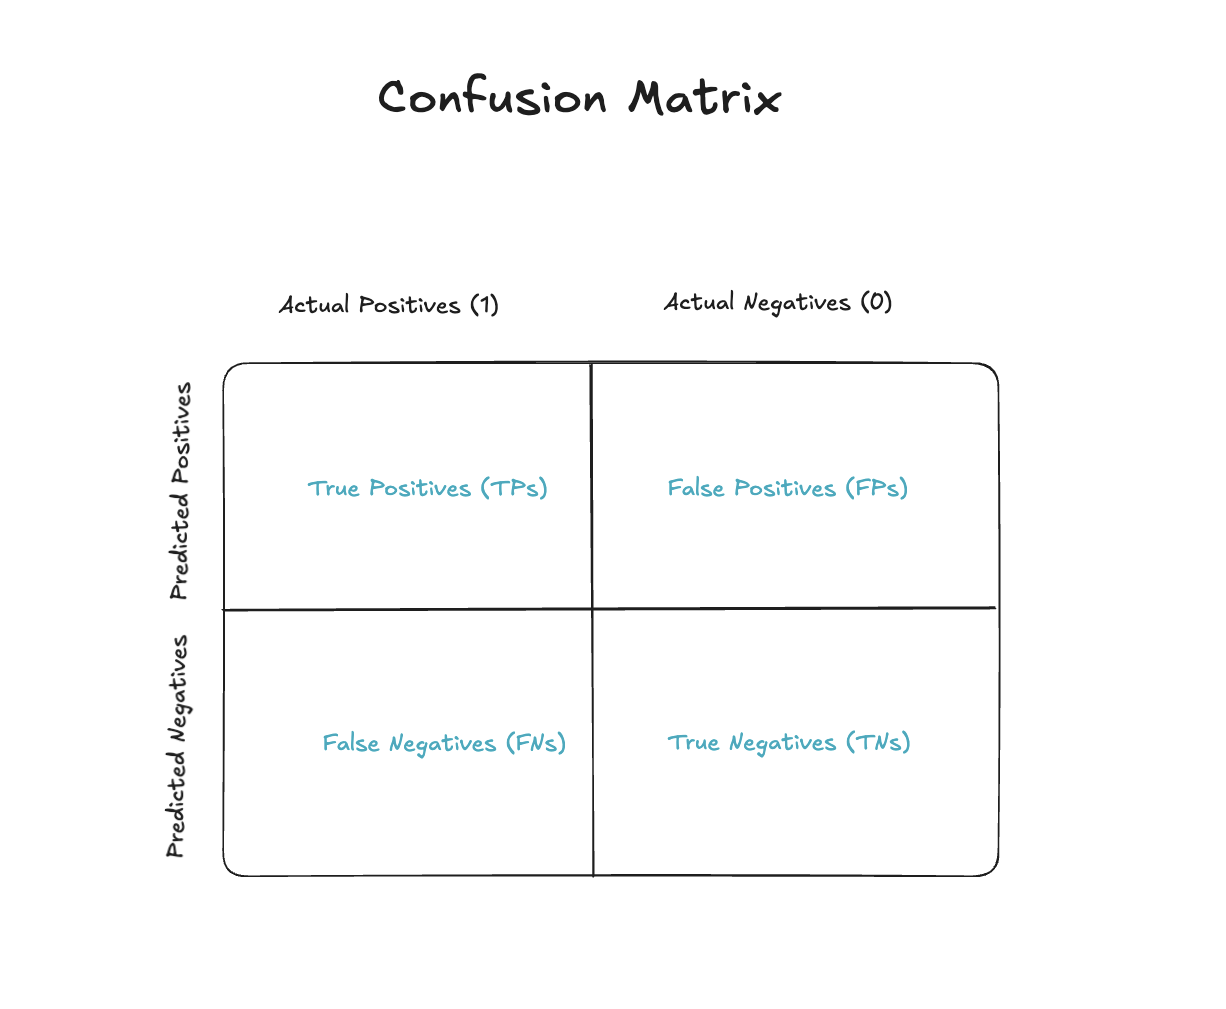

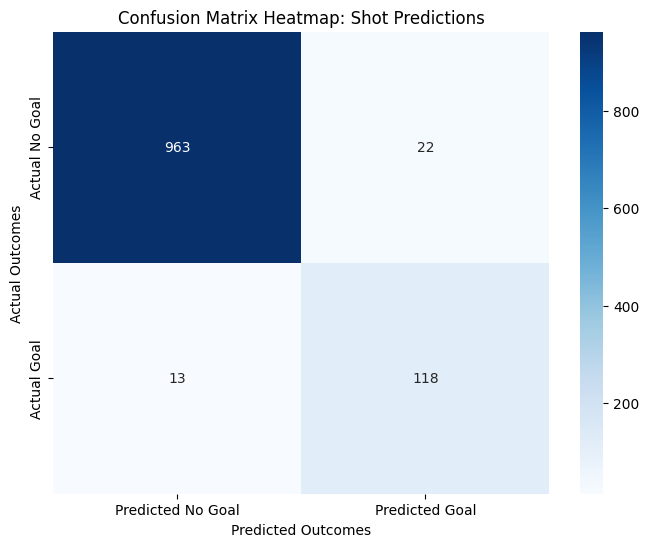

In [140]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)

plt.figure (figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted No Goal', 'Predicted Goal'], 
            yticklabels=['Actual No Goal', 'Actual Goal'])

plt.title('Confusion Matrix Heatmap: Shot Predictions')
plt.xlabel('Predicted Outcomes')
plt.ylabel('Actual Outcomes')
plt.show()


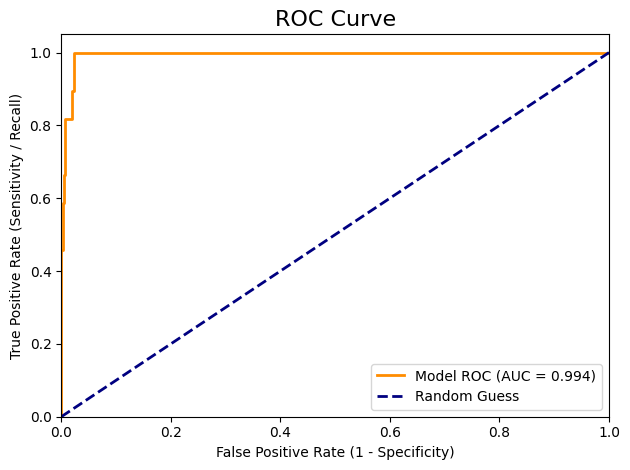

In [141]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_prob = cccv.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

auc_score = roc_auc_score(y_test, y_pred_prob)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Model ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve', fontsize=16)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

/var/folders/jj/50hzjhc91nl4xfr9hh_477pw0000gn/T/ipykernel_58896/1904840302.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y_train, palette=['blue', '#e74c3c'])


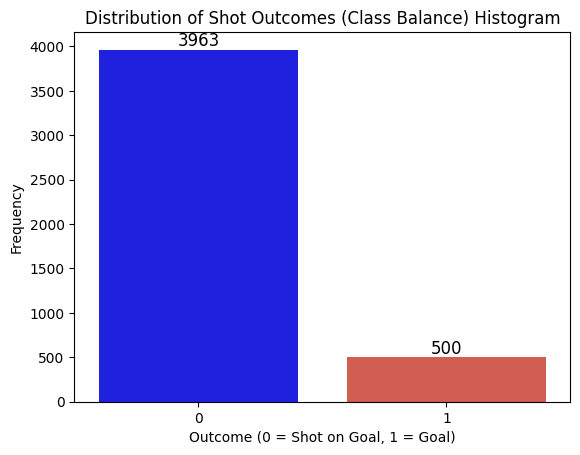

In [142]:
ax = sns.countplot(x=y_train, palette=['blue', '#e74c3c']) 

plt.title('Distribution of Shot Outcomes (Class Balance) Histogram')
plt.xlabel('Outcome (0 = Shot on Goal, 1 = Goal)')
plt.ylabel('Frequency')

# counts on top of the bars
for c in ax.containers:
    ax.bar_label(c, fmt='%d',fontsize=12)
plt.show()

### Discussion and Future Work

We utilize the accuracy precision, recall, and F1 scores to evaluate the behavior and the performance of the Calibrated classifier. 
Accuracy evaluates the ratio of correct predictions to the total number of predictions. Precision evaluates the true positive rate out of all predicted positive cases. Recall determines the True Positives(TPs) out of all actual positives in the data set. The F1 score demonstrated the mean of the precision and recall scores. These are all standard scoring metrics in machine learning models to evaluate the model's prediction rates. In classification models, these scoring metrics help data scientists understand if a model can be expanded, or if it needs more tuning.
This lets us determine the model's effectiveness and interpretability; while, also, providing the best classification model selection. 

Our model produced an accuracy score of 0.9686379928315412; a precision score of 0.8428571428571429; a recall score of 0.9007633587786259; and an F-1 score of 0.8708487084870848. 

With an accuracy score of .9686379928315412 and a precision score of .8428571428571429, I am confident in my model in future practice. These scores prove that the model would make accurate predictions on future data, meaning other NHL games and teams. Expanding this model would lead a more powerful way to evaluate individual player behaviors and metrics. Additionally, the model provided a high accuracy score without making any major modifications to the data (i.e. excluding large amounts of data, etc.) Certainly, there can be greater evaluations based on other factors in the data, such as including on-ice time for individual players. Adding additional model parameters would also fine-tune our model for better predictions. However, extensively fine-tuning our model can cause issues with predictions because of model parameters that might be too strict based on our current data. 

One of the larger issues that might occur with this model is variable bias. The model I've created is based on the exact position a shot is taken at, but does not include data from previous movements taken by players to make a shot, or the position of a goalie. In hockey games, the goalie can be removed from the game to provide offensive help in times of need. Specific situations like this might alter the model's ability to accurately predict a goal. Additionally, goals are only representative of about 10% of shot attempts. Because of this, the actual probability of scoring might also be determined on the lineup, time, and rank of teams in the game. 
